In [1]:
data = Import["C:\\Users\\Desktop\\Desktop\\programs\\SmCo5.wf", "Table"];
preFactorsRe = ToExpression[data[[All, 2]]];
preFactorsIm = ToExpression[data[[All, 3]]];
determinants = StringSplit[ToString[#], ""] & /@ ToString /@ data[[All, 4]];

mValues = Range[-3, 3];

detToOrbitals[det_] := {
   Pick[mValues, Take[det, 7], 1], 
   Pick[mValues, Take[det, {8, 14}], 1]  
};

validDeterminants = Select[determinants, Length[#] == 14 &];

orbitalSets = detToOrbitals /@ validDeterminants;

R4f[r_] := r^3 Exp[-r/4]; (* Radial part of the wavefunction *)
SphericalHarmonic[l_, m_][θ_, ϕ_] := SphericalHarmonicY[l, m, θ, ϕ];
OrbitalWavefunction[l_, m_][r_, θ_, ϕ_] := R4f[r] * SphericalHarmonic[l, m][θ, ϕ];

TotalWavefunction[r_, θ_, ϕ_] := 
  Total[
    (preFactorsRe[[#]] + I preFactorsIm[[#]]) *
      Total[OrbitalWavefunction[3, m][r, θ, ϕ] & /@ orbitalSets[[#]]] & /@ 
    Range[Length[orbitalSets]]
  ];

  OrbitalDensity[r_, θ_, ϕ_] := Abs[TotalWavefunction[r, θ, ϕ]]^2;

-Graphics3D-
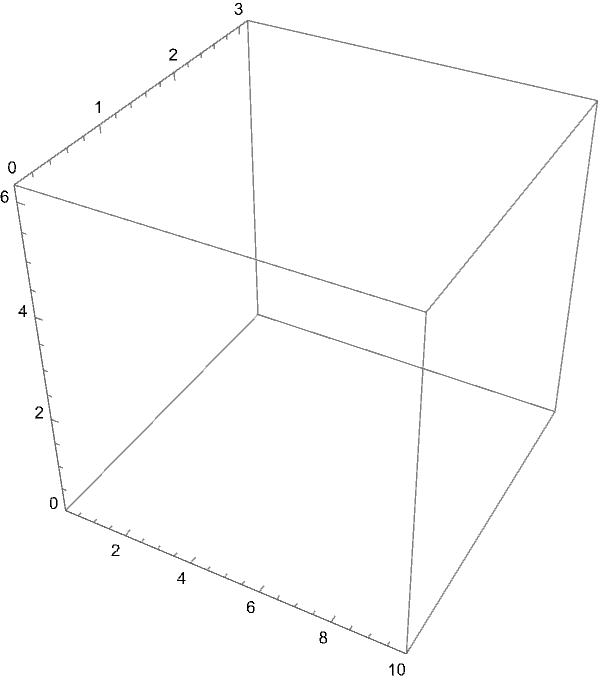

In [14]:
CartesianDensityData := 
  Flatten[
    Table[
      {r Sin[θ] Cos[ϕ], r Sin[θ] Sin[ϕ], r Cos[θ], 
       OrbitalDensity[r, θ, ϕ]}, 
      {r, 0.1, 10, 0.5}, {θ, 0, π, π/30}, {ϕ, 0, 2 π, π/30}
    ], 2
  ];

(* Filter points with significant density for visualization *)
(*filteredData = Select[CartesianDensityData, #[[4]] > 0.1 &];*)

(* Plot 3D orbital density *)
DensityPlot3D[OrbitalDensity[r, θ, ϕ], {r, 0.1, 10}, {θ, 0, π}, {ϕ, 0, 2 π}]

Sin::argx: Sin called with 2 arguments; 1 argument is expected.

Sin::argx: Sin called with 2 arguments; 1 argument is expected.

Sin::argx: Sin called with 2 arguments; 1 argument is expected.

General::stop: Further output of Sin::argx will be suppressed during this calculation.

-Graphics3D-
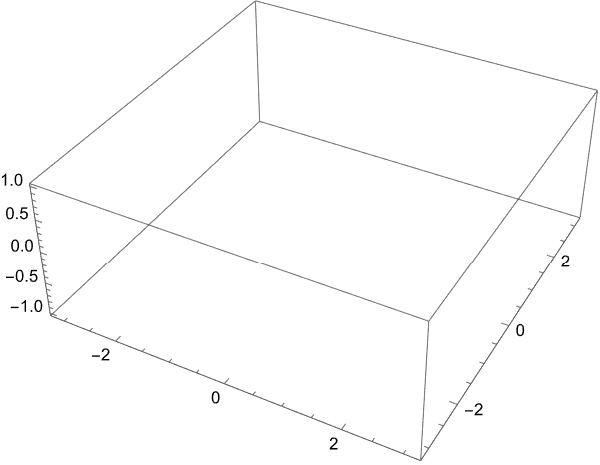